In [ ]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
# importamos los datasets
man1_coords = pd.read_csv("../data/raw/MAN1/MAN1_trncrd.csv", header=None, names=["x", "y", "z", "piso", "edificio"])
man1_rss = pd.read_csv("../data/raw/MAN1/MAN1_trnrss.csv", header=None)
uji1_coords = pd.read_csv("../data/raw/UJI1/UJI1_trncrd.csv", header=None, names=["x", "y", "z", "piso", "edificio"])
uji1_rss = pd.read_csv("../data/raw/UJI1/UJI1_trnrss.csv", header=None)
# QUITAR HEADS
print("Head MAN1 coords")
print(man1_coords.head())
print("Head MAN1 RSS")
print(man1_rss.head())
print("Head UJI1 coords")
print(uji1_coords.head())
print("Head UJI1 RSS")
print(uji1_rss.head())

Head MAN1 coords
      x      y  z  piso  edificio
0 -23.5 -10.75  0     0         0
1 -23.5 -10.75  0     0         0
2 -23.5 -10.75  0     0         0
3 -23.5 -10.75  0     0         0
4 -23.5 -10.75  0     0         0
Head MAN1 RSS
   0   1   2    3   4    5   6   7   8    9   ...   18   19   20   21   22  \
0 -53 -63 -74  -68 -73  -79 -72 -80 -85  -90  ...  100  100  100  100  100   
1 -50 -55 -79  -64 -69  -81 -75 -79 -85  -89  ...  100  100  100  100  100   
2 -52 -56 -73  100 -69  100 -71 -79 -85  100  ...  100  100  100  100  100   
3 -52 -54 -75  -67 -71  100 -71 -79 -86  -89  ...  100  100  100  100  100   
4 -51 -56 -80  -67 -72  100 -71 -76 -86  -88  ...  100  100  100  100  100   

    23   24   25   26   27  
0  100  100  100  100  100  
1  100  100  100  100  100  
2  100  100  100  100  100  
3  100  100  100  100  100  
4  100  100  100  100  100  

[5 rows x 28 columns]
Head UJI1 coords
           x             y    z  piso  edificio
0 -7541.2643  4.864921e+06  7.4   

# Materiales

## Datasets

En este notebook implementaremos el código necesario para la explicación de los materiales de nuestra investigación.

In [ ]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Ejecución en local")

# TENER EN CUENTA DESDE DÓNDE ESTAMOS EJECUTANDO PARA ENCONTRAR EL REQUIREMENTS
BASE_PATH = "/content/drive/MyDrive/TFMCode" if IN_COLAB else ".."

if IN_COLAB:
    drive.mount('/content/drive')
    print("Ejecución en colab")

    %pip install -r "{BASE_PATH}/requirements.txt"

Ejecución en local


Distribución espacial y de densidad de los datasets. Para MAN1 realizamos un scatter plot en 2D para visualizar la distribución en el plano del edificio de los puntos, mientras que para UJI1 realizamos un scatter plot en 3 dimensiones para aprovechar la naturaleza multiplanta y multiedificio del conjunto de datos.

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

def plot_spatial_distribution(df_coords):
    plt.figure(figsize=(10, 6))
    scatter = sns.scatterplot(
        data=df_coords, x='x', y='y',
        alpha=0.4, s=20, edgecolor=None
    )
    plt.xlabel('Coordenada X (m)')
    plt.ylabel('Coordenada Y (m)')
    plt.tight_layout()
    plt.show()

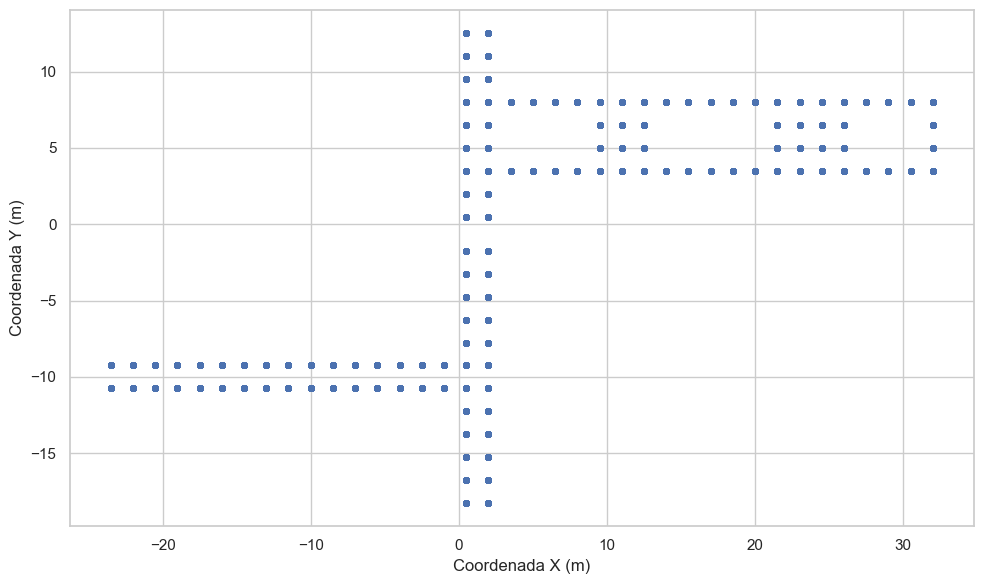

In [ ]:
plot_spatial_distribution(man1_coords)

In [ ]:
def plot_uji_3d(df_coords):
    fig = plt.figure(figsize=(14, 14))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(
        df_coords['x'], df_coords['y'], df_coords['z'],
        c=df_coords['edificio'], cmap='viridis', s=10, alpha=0.6
    )
    ax.view_init(elev=20, azim=45)
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Planta / Altura (Z)')

    plt.show()

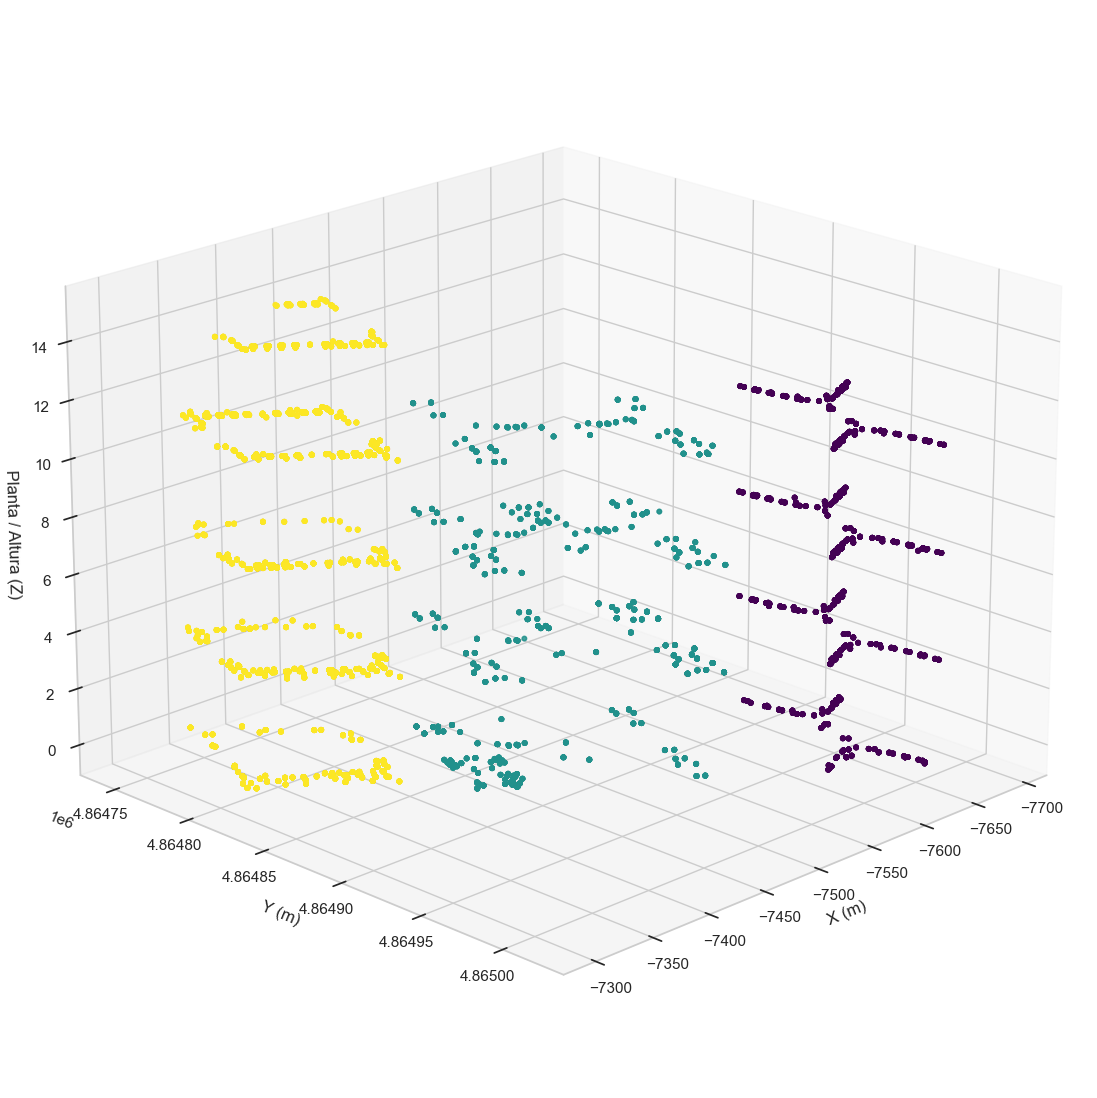

In [ ]:
plot_uji_3d(uji1_coords)

Histograma del análisis de la disponibilidad de la señal. Queremos ver cuál es el número de APs detectados por huella para identificar la justificación de la reducción del espacio de búsqueda.

In [ ]:
def plot_signal_sparsity(df_rss):
    detected_counts = ((df_rss > -110) & (df_rss != 100)).sum(axis=1)

    plt.figure(figsize=(8, 5))
    sns.histplot(detected_counts, bins=20, kde=True)
    plt.xlabel('Número de APs detectados por huella')
    plt.ylabel('Frecuencia')
    plt.show()

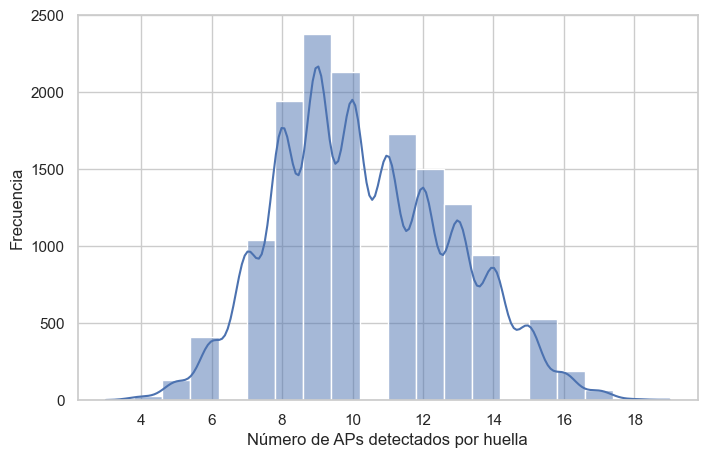

In [ ]:
plot_signal_sparsity(man1_rss)

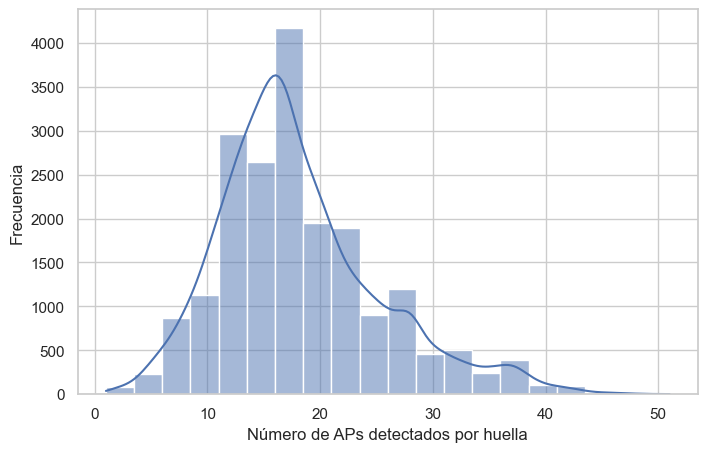

In [ ]:
plot_signal_sparsity(uji1_rss)